# **Подгоовка** данных по территории

## 1. Получение кварталов

### 1.1. Получение данных из **OpenStreetMap**. 
Этот шаг можно пропустить, если данные уже существуют.

In [ ]:
import osmnx as ox

boundaries = ox.geocode_to_gdf('Северодонецк, Украина')
boundaries.plot().set_axis_off()

In [ ]:
bc_tags = {
    'roads': {
      "highway": ["construction","crossing","living_street","motorway","motorway_link","motorway_junction","pedestrian","primary","primary_link","raceway","residential","road","secondary","secondary_link","services","tertiary","tertiary_link","track","trunk","trunk_link","turning_circle","turning_loop","unclassified",],
      "service": ["living_street", "emergency_access"]
    },
    'railways': {
      "railway": "rail"
    },
    'water': {
      'riverbank':True,
      'reservoir':True,
      'basin':True,
      'dock':True,
      'canal':True,
      'pond':True,
      'natural':['water','bay'],
      'waterway':['river','canal','ditch'],
      'landuse':'basin',
      'water': 'lake'
    }
}

In [ ]:
water = ox.features_from_polygon(boundaries.union_all(), bc_tags['water'])
roads = ox.features_from_polygon(boundaries.union_all(), bc_tags['roads'])
railways = ox.features_from_polygon(boundaries.union_all(), bc_tags['railways'])

In [ ]:
water = water[water.geom_type.isin(['Polygon', 'MultiPolygon', 'LineString', 'MultiLineString'])].copy()
roads = roads[roads.geom_type.isin(['LineString', 'MultiLineString'])].copy()
railways = railways[railways.geom_type.isin(['LineString', 'MultiLineString'])].copy()

In [ ]:
crs = boundaries.estimate_utm_crs()

for gdf in [water, roads, railways, boundaries]:
  gdf.to_crs(crs, inplace=True)

### 1.2. Предварительная обработка входной геометрии

Этот шаг можно пропустить, если входная геометрия уже отсортирована как линии, многоугольники и границы.

In [ ]:
roads = roads.reset_index(drop=True)
railways = railways.reset_index(drop=True)
water = water.reset_index(drop=True)

In [ ]:
from blocksnet.blocks.cutting import preprocess_urban_objects, cut_urban_blocks

lines, polygons = preprocess_urban_objects(roads, railways, water)

2025-12-12 17:49:38.790 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:44 - Checking roads schema
2025-12-12 17:49:38.799 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:51 - Checking railways schema
2025-12-12 17:49:38.804 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:58 - Checking water schema


### 1.3. **Нарезка** городских кварталов

2025-12-12 17:49:38.815 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:51 - Checking boundaries schema
2025-12-12 17:49:38.820 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:55 - Checking line objects schema
2025-12-12 17:49:38.827 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:62 - Checking polygon objects schema
2025-12-12 17:49:38.834 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:69 - Checking buildings schema
2025-12-12 17:49:38.835 | WARNING  | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:71 - Creating empty buildings
2025-12-12 17:49:38.894 | SUCCESS  | blocksnet.blocks.cutting.processing.core:cut_urban_blocks:26 - 452 blocks are successfully cut


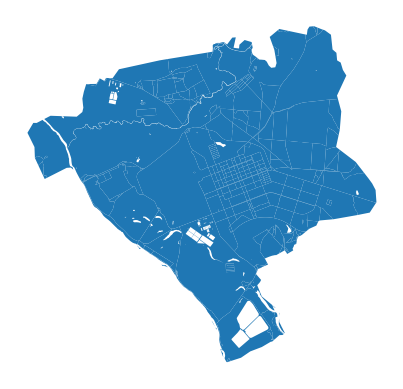

In [ ]:
blocks = cut_urban_blocks(boundaries, lines, polygons)
blocks.plot().set_axis_off()

___


## 2. Назначение **землепользования**


### 2.1. Получение данных из OpenStreetMap

Этот шаг можно пропустить, если слой функциональных зон уже получен из государственных источников.

In [ ]:
import osmnx as ox

functional_zones = ox.features_from_polygon(boundaries.to_crs(4326).union_all(), tags={'landuse': True})

In [ ]:
functional_zones = functional_zones.reset_index(drop=True)[['geometry','landuse']].rename(columns={'landuse': 'functional_zone'})
functional_zones = functional_zones.to_crs(crs)
functional_zones.head()

,geometry,functional_zone
0,"POLYGON ((462670.73 5422457.135, 462672.663 54...",grass
1,"POLYGON ((462931.865 5421793.457, 462958.314 5...",grass
2,"POLYGON ((462870.376 5421765.263, 462872.985 5...",grass
3,"POLYGON ((462919.772 5421777.44, 462921.912 54...",grass
4,"POLYGON ((458953.908 5420349.97, 458958.846 54...",forest



### 2.2. Указание правил

Правила определяют, как столбец `functional_zone` будет отображаться в `LandUse`.

In [ ]:
from blocksnet.enums import LandUse

rules = {
  'commercial': LandUse.BUSINESS,
  'industrial': LandUse.INDUSTRIAL,
  'cemetery': LandUse.SPECIAL,
  'garages': LandUse.INDUSTRIAL,
  'residential': LandUse.RESIDENTIAL,
  'retail': LandUse.BUSINESS,
  'grass': LandUse.RECREATION,
  'farmland': LandUse.AGRICULTURE,
  'construction': LandUse.SPECIAL,
  'brownfield': LandUse.INDUSTRIAL,
  'forest': LandUse.RECREATION,
  'recreation_ground': LandUse.RECREATION,
  'religious': LandUse.SPECIAL,
  'flowerbed': LandUse.RECREATION,
  'military': LandUse.SPECIAL,
  'landfill': LandUse.TRANSPORT
}

### 2.3. Назначение земплепользования 

In [ ]:
from blocksnet.blocks.assignment import assign_land_use

blocks = assign_land_use(blocks, functional_zones.reset_index(drop=True).rename(columns={'landuse': 'functional_zone'}), rules)

2025-12-12 17:49:41.537 | WARNING  | blocksnet.blocks.assignment.land_use:_preprocess_functional_zones:17 - Functional zones not in rules: greenfield, basin, farmyard, meadow, allotments, reservoir, quarry, greenhouse_horticulture, common, orchard, village_green


In [ ]:
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((461023.277 5423900.675, 461059.156 5...",0.041121,0.325642,0.000962,0.436797,0.0,0.002426,0.0,LandUse.INDUSTRIAL,0.436797
1,"POLYGON ((461283.489 5423886.895, 461255.375 5...",0.008932,0.000000,0.135694,0.167765,0.0,0.000322,0.0,LandUse.INDUSTRIAL,0.167765
2,"POLYGON ((461382.815 5423863.859, 461370.049 5...",0.000000,0.000000,0.726647,0.000000,0.0,0.000000,0.0,LandUse.RECREATION,0.726647
3,"POLYGON ((461618.612 5423807.775, 461577.814 5...",0.000000,0.000000,0.876683,0.027481,0.0,0.000000,0.0,LandUse.RECREATION,0.876683
4,"POLYGON ((461618.612 5423807.775, 461626.015 5...",0.033228,0.000000,0.231941,0.031573,0.0,0.005520,0.0,LandUse.RECREATION,0.231941


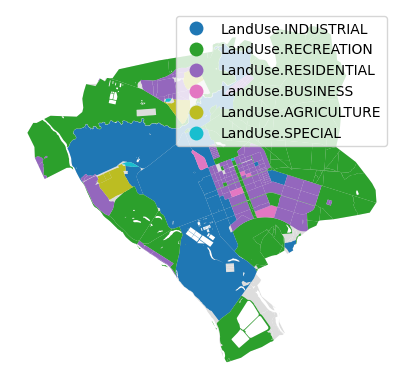

In [ ]:
ax = blocks.plot(color='#ddd')
blocks.plot(column='land_use', legend=True, ax=ax).set_axis_off()

___

## 3. Расчет матрицы доступности

Существует несколько способов определения пространственных связей между городскими кварталами:
- **Матрица доступности** - матрица `n ^ 2`, которая определяет время в пути между центроидами городских кварталов в минутах.
- **Матрица расстояний** - матрица `n ^ 2`, которая определяет евклидово расстояние между центроидами городских кварталов в метрах.
- **График смежности** - график с `n` узлами. Каждое ребро этого графика указывает на пространственную смежность двух городских кварталов.

В этом примере **матрица доступности** будет рассчитана с использованием библиотеки IduEdu.

### 3.1. Построение интермодальных графов

Существует несколько типов городских графов для моделирования городской сети:
- **walk** - пешеходная сеть.
- **drive** - сеть личного транспорта.
- **интермодальная** - сеть пешеходного и общественного транспорта.

В этом примере будет построен **интермодальный** график, но в целом это зависит от результатов исследования.

In [ ]:
from blocksnet.relations import get_accessibility_graph

graph = get_accessibility_graph(boundaries, 'intermodal')

2025-12-12 18:32:39.747 | INFO     | iduedu.modules.drive_walk_builder:get_walk_graph:217 - Downloading walk graph from OSM, it may take a while for large territory ...


Parsing public transport routes:   0%|          | 0/21 [00:00<?, ?it/s]

/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/iduedu/modules/routes_parser.py:270: UserWarning: В одном из маршрутов нет пути, пока не работаю с этим
  warnings.warn("В одном из маршрутов нет пути, пока не работаю с этим", UserWarning)


Calculating the weights of the walk graph:   0%|          | 0/31958 [00:00<?, ?it/s]

2025-12-12 18:32:49.034 | INFO     | iduedu.modules.pt_walk_joiner:join_pt_walk_graph:51 - Composing intermodal graph...
2025-12-12 18:32:49.798 | WARNING  | iduedu.utils.utils:remove_weakly_connected_nodes:27 - Found 2 disconnected subgraphs in the network. These are isolated groups of nodes with no connections between them. Size of components: [54, 11857]
2025-12-12 18:32:49.820 | WARNING  | iduedu.utils.utils:remove_weakly_connected_nodes:37 - Removing 89 nodes that form 44 trap components. These are groups where you can enter but can't exit (or vice versa). Keeping the largest strongly connected component (11822 nodes).


### 3.2. Вычисление матрицы доступности

In [ ]:
from blocksnet.relations import calculate_accessibility_matrix

acc_mx = calculate_accessibility_matrix(blocks, graph)

In [ ]:
acc_mx.head()

/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,0,1,2,3,4,5,6,7,8,9,...,442,443,444,445,446,447,448,449,450,451
0,0.000000,27.50000,12.648438,26.031250,20.171875,29.625000,35.656250,53.90625,36.96875,42.40625,...,108.7500,110.1875,82.0625,74.87500,76.4375,108.375,108.6875,24.109375,29.203125,31.328125
1,27.500000,0.00000,17.593750,28.343750,28.796875,37.906250,37.250000,55.50000,38.59375,44.03125,...,110.3750,111.8125,83.6875,76.50000,68.6875,110.000,110.2500,16.343750,19.500000,33.656250
2,12.648438,17.59375,0.000000,14.968750,18.078125,22.031250,35.125000,53.37500,36.46875,41.87500,...,108.2500,109.6875,81.5625,74.37500,66.5625,107.875,108.1250,14.210938,19.312500,20.265625
3,26.031250,28.34375,14.968750,0.000000,29.234375,30.187500,45.906250,64.12500,47.21875,52.62500,...,118.9375,120.3750,92.3125,85.06250,77.2500,118.625,118.8750,24.968750,30.062500,20.875000
4,20.171875,27.46875,18.078125,29.234375,0.000000,10.265625,23.640625,41.87500,24.96875,30.37500,...,96.6875,98.1250,70.0625,62.84375,71.4375,96.375,96.6250,19.093750,29.187500,32.968750


### 3.3 Вычисления **связанности**

#### Вычисления **площади участка**

In [ ]:
import pandas as pd

blocks['site_area'] = blocks.area
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,site_area
0,"POLYGON ((461023.277 5423900.675, 461059.156 5...",0.041121,0.325642,0.000962,0.436797,0.0,0.002426,0.0,LandUse.INDUSTRIAL,0.436797,1.006466e+06
1,"POLYGON ((461283.489 5423886.895, 461255.375 5...",0.008932,0.000000,0.135694,0.167765,0.0,0.000322,0.0,LandUse.INDUSTRIAL,0.167765,9.493442e+06
2,"POLYGON ((461382.815 5423863.859, 461370.049 5...",0.000000,0.000000,0.726647,0.000000,0.0,0.000000,0.0,LandUse.RECREATION,0.726647,2.413988e+04
3,"POLYGON ((461618.612 5423807.775, 461577.814 5...",0.000000,0.000000,0.876683,0.027481,0.0,0.000000,0.0,LandUse.RECREATION,0.876683,6.933567e+05
4,"POLYGON ((461618.612 5423807.775, 461626.015 5...",0.033228,0.000000,0.231941,0.031573,0.0,0.005520,0.0,LandUse.RECREATION,0.231941,8.537681e+05


In [ ]:
from blocksnet.analysis.network.accessibility import area_accessibility
# matrix = pd.read_pickle('./data/niipg/matrix.pickle')

In [ ]:
area_acc = area_accessibility(acc_mx, blocks)
blocks = blocks.join(area_acc)

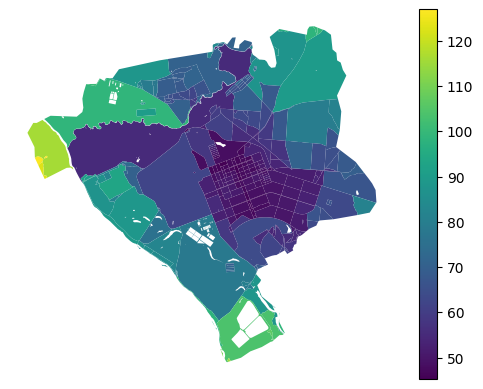

In [ ]:
blocks.plot('area_accessibility', legend=True).set_axis_off()

___

## 4. Вычисления **показателей застройки**

Здания определяют параметры городской среды в разных блоках. Для некоторых методов blocksnet может использоваться только население, но в целом здание определяется с помощью:

- `population : float`
- `footprint_area : float` - базовая площадь здания.
- `number_of_floors : float`
- `build_floor_area : float` - суммарная площадь каждого этажа здания
- `is_living : bool`
- `жилая_площадь : float` - площадь, определенная для жителей
- `non_living_area : float` - область, в которой не определено место проживания

Некоторые из этих параметров могут быть отсутствовать в данных, и в этом случае они будут установлены в значение по умолчанию.

### 4.1. Извлечение зданий из OpenStreetMap

Этот шаг можно пропустить, если данные уже получены из любого доступного источника.

In [ ]:
buildings = ox.features_from_polygon(boundaries.to_crs(4326).union_all(), tags={'building': True}).reset_index(drop=True).to_crs(crs)

#### 4.1.1. `is_living`

In [ ]:
is_living_tags = ['residential', 'house', 'apartments', 'detached', 'terrace', 'dormitory']
buildings['is_living'] = buildings['building'].apply(lambda b : b in is_living_tags)

#### 4.1.2. `number_of_floors`

In [ ]:
import pandas as pd

buildings['number_of_floors'] = pd.to_numeric(buildings['building:levels'], errors='coerce')
buildings['number_of_floors'] = buildings['number_of_floors'].clip(lower=1)

In [ ]:
required = {'site_area', 'footprint_area', 'build_floor_area', 'living_area'}
missing = required - set(buildings.columns)
print(missing)

{'site_area', 'footprint_area', 'living_area', 'build_floor_area'}


### 4.2. **Восполнение** недостающих данных

In [ ]:
from blocksnet.preprocessing.imputing import impute_buildings

buildings = impute_buildings(buildings, default_living_demand=30)

2025-12-12 18:33:10.792 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column footprint_area not found and will be initialized as None
2025-12-12 18:33:10.793 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column build_floor_area not found and will be initialized as None
2025-12-12 18:33:10.793 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column living_area not found and will be initialized as None
2025-12-12 18:33:10.793 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column non_living_area not found and will be initialized as None


2025-12-12 18:33:10.794 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column population not found and will be initialized as None


In [ ]:
buildings.sample(5)

,geometry,is_living,number_of_floors,footprint_area,build_floor_area,living_area,non_living_area,population
407,"POLYGON ((462234.775 5422509.726, 462270.573 5...",False,1.0,434.903432,434.903432,0.000000,434.903432,NaN
7320,"POLYGON ((463013.845 5420517.942, 463018.178 5...",False,1.0,24.973787,24.973787,0.000000,24.973787,NaN
2239,"POLYGON ((463184.064 5421936.39, 463177.817 54...",False,1.0,26.852572,26.852572,0.000000,26.852572,NaN
203,"POLYGON ((463645.396 5421408.207, 463647.62 54...",True,4.0,863.773718,3455.094873,3109.585386,345.509487,103.0
202,"POLYGON ((463758.16 5421261.397, 463759.902 54...",False,1.0,70.313495,70.313495,0.000000,70.313495,NaN


In [ ]:
buildings.population.sum()

np.float64(100461.0)

### 4.3. Перенос зданий в городские кварталы

In [ ]:
from blocksnet.blocks.aggregation import aggregate_objects

buildings_blocks = aggregate_objects(blocks, buildings)[0]

2025-12-12 18:33:22.508 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2025-12-12 18:33:22.513 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects


In [ ]:
buildings_blocks.head()

,geometry,is_living,number_of_floors,footprint_area,build_floor_area,living_area,non_living_area,population,count
0,"POLYGON ((461023.277 5423900.675, 461059.156 5...",25.0,244.0,115686.562996,187575.948456,5654.109398,181921.839057,174.0,191.0
1,"POLYGON ((461283.489 5423886.895, 461255.375 5...",131.0,350.0,183016.833928,296651.912249,7149.014205,289502.898044,214.0,296.0
2,"POLYGON ((461382.815 5423863.859, 461370.049 5...",0.0,1.0,95.344901,95.344901,0.000000,95.344901,0.0,1.0
3,"POLYGON ((461618.612 5423807.775, 461577.814 5...",0.0,9.0,1009.962399,1153.761728,0.000000,1153.761728,0.0,8.0
4,"POLYGON ((461618.612 5423807.775, 461626.015 5...",2.0,152.0,38958.760678,89530.031390,11865.540009,77664.491381,395.0,103.0


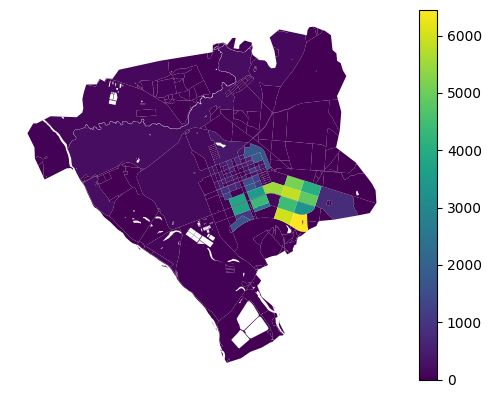

In [ ]:
buildings_blocks.plot('population', legend=True).set_axis_off()

In [ ]:
blocks = blocks.join(buildings_blocks.drop(columns=['geometry']))
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,site_area,area_accessibility,is_living,number_of_floors,footprint_area,build_floor_area,living_area,non_living_area,population,count
0,"POLYGON ((461023.277 5423900.675, 461059.156 5...",0.041121,0.325642,0.000962,0.436797,0.0,0.002426,0.0,LandUse.INDUSTRIAL,0.436797,1.006466e+06,58.051708,25.0,244.0,115686.562996,187575.948456,5654.109398,181921.839057,174.0,191.0
1,"POLYGON ((461283.489 5423886.895, 461255.375 5...",0.008932,0.000000,0.135694,0.167765,0.0,0.000322,0.0,LandUse.INDUSTRIAL,0.167765,9.493442e+06,54.873621,131.0,350.0,183016.833928,296651.912249,7149.014205,289502.898044,214.0,296.0
2,"POLYGON ((461382.815 5423863.859, 461370.049 5...",0.000000,0.000000,0.726647,0.000000,0.0,0.000000,0.0,LandUse.RECREATION,0.726647,2.413988e+04,52.880546,0.0,1.0,95.344901,95.344901,0.000000,95.344901,0.0,1.0
3,"POLYGON ((461618.612 5423807.775, 461577.814 5...",0.000000,0.000000,0.876683,0.027481,0.0,0.000000,0.0,LandUse.RECREATION,0.876683,6.933567e+05,61.216910,0.0,9.0,1009.962399,1153.761728,0.000000,1153.761728,0.0,8.0
4,"POLYGON ((461618.612 5423807.775, 461626.015 5...",0.033228,0.000000,0.231941,0.031573,0.0,0.005520,0.0,LandUse.RECREATION,0.231941,8.537681e+05,48.333106,2.0,152.0,38958.760678,89530.031390,11865.540009,77664.491381,395.0,103.0


_____


## 5. Морфотипы 

### 5.1 Вычисление плотности застройки

In [ ]:
from blocksnet.analysis.indicators import calculate_density_indicators 

density_df = calculate_density_indicators(blocks[[
    'site_area',
    'footprint_area',
    'build_floor_area',
    'living_area'
]])
density_df.head()

2025-12-12 18:33:29.022 | WARNING  | blocksnet.analysis.indicators.density.schemas:_before_validate:19 - The non_living_area is not in columns, restoring


,site_area,footprint_area,build_floor_area,living_area,non_living_area,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,1.006466e+06,115686.562996,187575.948456,5654.109398,181921.839057,0.186371,0.114943,0.030143,1.621415,4.748902,0.048874,1.572541
1,9.493442e+06,183016.833928,296651.912249,7149.014205,289502.898044,0.031248,0.019278,0.024099,1.620900,31.385016,0.039062,1.581838
2,2.413988e+04,95.344901,95.344901,0.000000,95.344901,0.003950,0.003950,0.000000,1.000000,252.184769,0.000000,1.000000
3,6.933567e+05,1009.962399,1153.761728,0.000000,1153.761728,0.001664,0.001457,0.000000,1.142381,600.077765,0.000000,1.142381
4,8.537681e+05,38958.760678,89530.031390,11865.540009,77664.491381,0.104865,0.045632,0.132531,2.298072,9.100961,0.304567,1.993505


In [ ]:
blocks.loc[:, density_df.columns] = density_df
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,non_living_area,population,count,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,"POLYGON ((461023.277 5423900.675, 461059.156 5...",0.041121,0.325642,0.000962,0.436797,0.0,0.002426,0.0,LandUse.INDUSTRIAL,0.436797,...,181921.839057,174.0,191.0,0.186371,0.114943,0.030143,1.621415,4.748902,0.048874,1.572541
1,"POLYGON ((461283.489 5423886.895, 461255.375 5...",0.008932,0.000000,0.135694,0.167765,0.0,0.000322,0.0,LandUse.INDUSTRIAL,0.167765,...,289502.898044,214.0,296.0,0.031248,0.019278,0.024099,1.620900,31.385016,0.039062,1.581838
2,"POLYGON ((461382.815 5423863.859, 461370.049 5...",0.000000,0.000000,0.726647,0.000000,0.0,0.000000,0.0,LandUse.RECREATION,0.726647,...,95.344901,0.0,1.0,0.003950,0.003950,0.000000,1.000000,252.184769,0.000000,1.000000
3,"POLYGON ((461618.612 5423807.775, 461577.814 5...",0.000000,0.000000,0.876683,0.027481,0.0,0.000000,0.0,LandUse.RECREATION,0.876683,...,1153.761728,0.0,8.0,0.001664,0.001457,0.000000,1.142381,600.077765,0.000000,1.142381
4,"POLYGON ((461618.612 5423807.775, 461626.015 5...",0.033228,0.000000,0.231941,0.031573,0.0,0.005520,0.0,LandUse.RECREATION,0.231941,...,77664.491381,395.0,103.0,0.104865,0.045632,0.132531,2.298072,9.100961,0.304567,1.993505


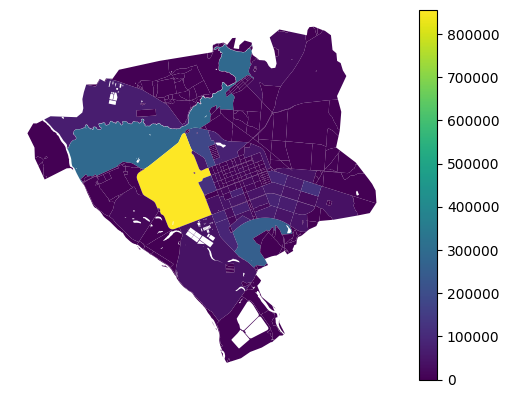

In [ ]:
blocks.plot('non_living_area', legend=True).set_axis_off()

### 5.1 Вычисления морфотипов

In [ ]:
# from blocksnet.analysis.morphotypes import get_spacematrix_morphotypes

# spacematrix_df, spacematrix_clusters = get_spacematrix_morphotypes(blocks)
# blocks.loc[:, spacematrix_df.columns] = spacematrix_df
# blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,count,fsi,gsi,mxi,l,osr,share_living,share_non_living,cluster,morphotype
0,"POLYGON ((461023.277 5423900.675, 461059.156 5...",0.041121,0.325642,0.000962,0.436797,0.0,0.002426,0.0,LandUse.INDUSTRIAL,0.436797,...,191.0,0.186371,0.114943,0.030143,1.621415,4.748902,0.048874,1.572541,9.0,low-rise low-density non-residential
1,"POLYGON ((461283.489 5423886.895, 461255.375 5...",0.008932,0.000000,0.135694,0.167765,0.0,0.000322,0.0,LandUse.INDUSTRIAL,0.167765,...,296.0,0.031248,0.019278,0.024099,1.620900,31.385016,0.039062,1.581838,7.0,low-rise low-density non-residential
2,"POLYGON ((461382.815 5423863.859, 461370.049 5...",0.000000,0.000000,0.726647,0.000000,0.0,0.000000,0.0,LandUse.RECREATION,0.726647,...,1.0,0.003950,0.003950,0.000000,1.000000,252.184769,0.000000,1.000000,7.0,low-rise low-density non-residential
3,"POLYGON ((461618.612 5423807.775, 461577.814 5...",0.000000,0.000000,0.876683,0.027481,0.0,0.000000,0.0,LandUse.RECREATION,0.876683,...,8.0,0.001664,0.001457,0.000000,1.142381,600.077765,0.000000,1.142381,7.0,low-rise low-density non-residential
4,"POLYGON ((461618.612 5423807.775, 461626.015 5...",0.033228,0.000000,0.231941,0.031573,0.0,0.005520,0.0,LandUse.RECREATION,0.231941,...,103.0,0.104865,0.045632,0.132531,2.298072,9.100961,0.304567,1.993505,9.0,low-rise low-density non-residential


In [ ]:
from blocksnet.analysis.morphotypes import get_strelka_morphotypes

strelka_df = get_strelka_morphotypes(blocks)
blocks.loc[:, strelka_df.columns] = strelka_df
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,population,count,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype
0,"POLYGON ((461023.277 5423900.675, 461059.156 5...",0.041121,0.325642,0.000962,0.436797,0.0,0.002426,0.0,LandUse.INDUSTRIAL,0.436797,...,174.0,191.0,0.186371,0.114943,0.030143,1.621415,4.748902,0.048874,1.572541,low-rise non-residential
1,"POLYGON ((461283.489 5423886.895, 461255.375 5...",0.008932,0.000000,0.135694,0.167765,0.0,0.000322,0.0,LandUse.INDUSTRIAL,0.167765,...,214.0,296.0,0.031248,0.019278,0.024099,1.620900,31.385016,0.039062,1.581838,low-rise non-residential
2,"POLYGON ((461382.815 5423863.859, 461370.049 5...",0.000000,0.000000,0.726647,0.000000,0.0,0.000000,0.0,LandUse.RECREATION,0.726647,...,0.0,1.0,0.003950,0.003950,0.000000,1.000000,252.184769,0.000000,1.000000,low-rise non-residential
3,"POLYGON ((461618.612 5423807.775, 461577.814 5...",0.000000,0.000000,0.876683,0.027481,0.0,0.000000,0.0,LandUse.RECREATION,0.876683,...,0.0,8.0,0.001664,0.001457,0.000000,1.142381,600.077765,0.000000,1.142381,low-rise non-residential
4,"POLYGON ((461618.612 5423807.775, 461626.015 5...",0.033228,0.000000,0.231941,0.031573,0.0,0.005520,0.0,LandUse.RECREATION,0.231941,...,395.0,103.0,0.104865,0.045632,0.132531,2.298072,9.100961,0.304567,1.993505,low-rise model


In [ ]:
# blocks.to_file('severodonetsk_blocks.geojson')

/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: NaN of Infinity value found. Skipped
  ogr_write(


# **Urbanomy**

In [1]:
import geopandas as gpd
import numpy as np
blocks = gpd.read_file('./data/severodonetsk_blocks.geojson')

In [2]:
cols = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]
basline_blocks = blocks[cols]
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,non_living_area,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry
0,0.041121,0.325642,0.000962,0.436797,0.0,0.002426,0.0,LandUse.INDUSTRIAL,0.436797,115686.562996,...,181921.839057,174.0,1.006466e+06,0.186371,0.114943,0.030143,1.621415,low-rise low-density non-residential,58.051708,"POLYGON ((461023.277 5423900.675, 461059.156 5..."
1,0.008932,0.000000,0.135694,0.167765,0.0,0.000322,0.0,LandUse.INDUSTRIAL,0.167765,183016.833928,...,289502.898044,214.0,9.493442e+06,0.031248,0.019278,0.024099,1.620900,low-rise low-density non-residential,54.873621,"POLYGON ((461283.489 5423886.895, 461255.375 5..."
2,0.000000,0.000000,0.726647,0.000000,0.0,0.000000,0.0,LandUse.RECREATION,0.726647,95.344901,...,95.344901,0.0,2.413988e+04,0.003950,0.003950,0.000000,1.000000,low-rise low-density non-residential,52.880546,"POLYGON ((461382.815 5423863.859, 461370.049 5..."
3,0.000000,0.000000,0.876683,0.027481,0.0,0.000000,0.0,LandUse.RECREATION,0.876683,1009.962399,...,1153.761728,0.0,6.933567e+05,0.001664,0.001457,0.000000,1.142381,low-rise low-density non-residential,61.216910,"POLYGON ((461618.612 5423807.775, 461577.814 5..."
4,0.033228,0.000000,0.231941,0.031573,0.0,0.005520,0.0,LandUse.RECREATION,0.231941,38958.760678,...,77664.491381,395.0,8.537681e+05,0.104865,0.045632,0.132531,2.298072,low-rise low-density non-residential,48.333106,"POLYGON ((461618.612 5423807.775, 461626.015 5..."


___

## Предсказание **стоимости земельных участков**

In [3]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('./data/catboost_model.cbm')  # модель на лог-цене

estimator = LandPriceEstimator(
    model=model,
    blocks=basline_blocks,
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,land_value
0,0.041121,0.325642,0.000962,0.436797,0.0,0.002426,0.0,LandUse.INDUSTRIAL,0.436797,115686.562996,...,174.0,1.006466e+06,0.186371,0.114943,0.030143,1.621415,low-rise low-density non-residential,58.051708,"POLYGON ((461023.277 5423900.675, 461059.156 5...",1.309775e+09
1,0.008932,0.000000,0.135694,0.167765,0.0,0.000322,0.0,LandUse.INDUSTRIAL,0.167765,183016.833928,...,214.0,9.493442e+06,0.031248,0.019278,0.024099,1.620900,low-rise low-density non-residential,54.873621,"POLYGON ((461283.489 5423886.895, 461255.375 5...",1.451285e+09
2,0.000000,0.000000,0.726647,0.000000,0.0,0.000000,0.0,LandUse.RECREATION,0.726647,95.344901,...,0.0,2.413988e+04,0.003950,0.003950,0.000000,1.000000,low-rise low-density non-residential,52.880546,"POLYGON ((461382.815 5423863.859, 461370.049 5...",1.793846e+07
3,0.000000,0.000000,0.876683,0.027481,0.0,0.000000,0.0,LandUse.RECREATION,0.876683,1009.962399,...,0.0,6.933567e+05,0.001664,0.001457,0.000000,1.142381,low-rise low-density non-residential,61.216910,"POLYGON ((461618.612 5423807.775, 461577.814 5...",3.785562e+08
4,0.033228,0.000000,0.231941,0.031573,0.0,0.005520,0.0,LandUse.RECREATION,0.231941,38958.760678,...,395.0,8.537681e+05,0.104865,0.045632,0.132531,2.298072,low-rise low-density non-residential,48.333106,"POLYGON ((461618.612 5423807.775, 461626.015 5...",1.118270e+09


count       447.000000
mean     198648.350545
std      162038.632866
min        5011.071087
25%       70274.743199
50%      129073.737541
75%      308592.461351
max      609249.246529
Name: land_value_per_100m2, dtype: float64


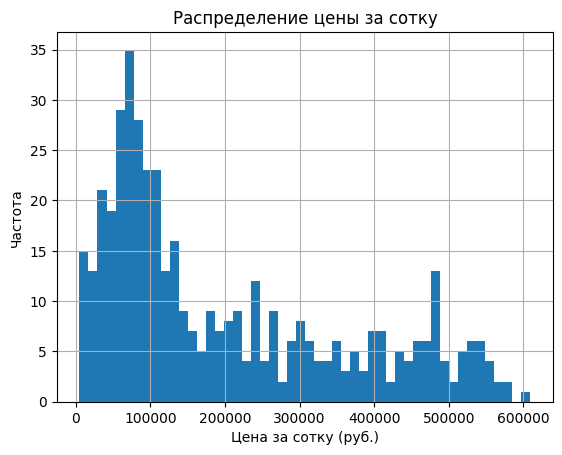

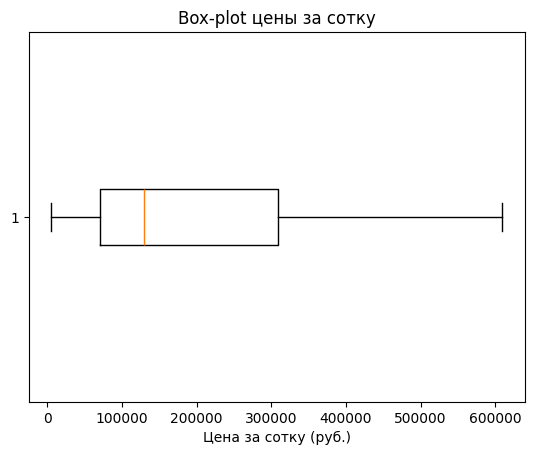

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.99)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()

# 5) Box-plot после очистки
plt.figure()
plt.boxplot(blocks_clean["land_value_per_100m2"].dropna(), vert=False)
plt.xlabel("Цена за сотку (руб.)")
plt.title("Box-plot цены за сотку")
plt.show()


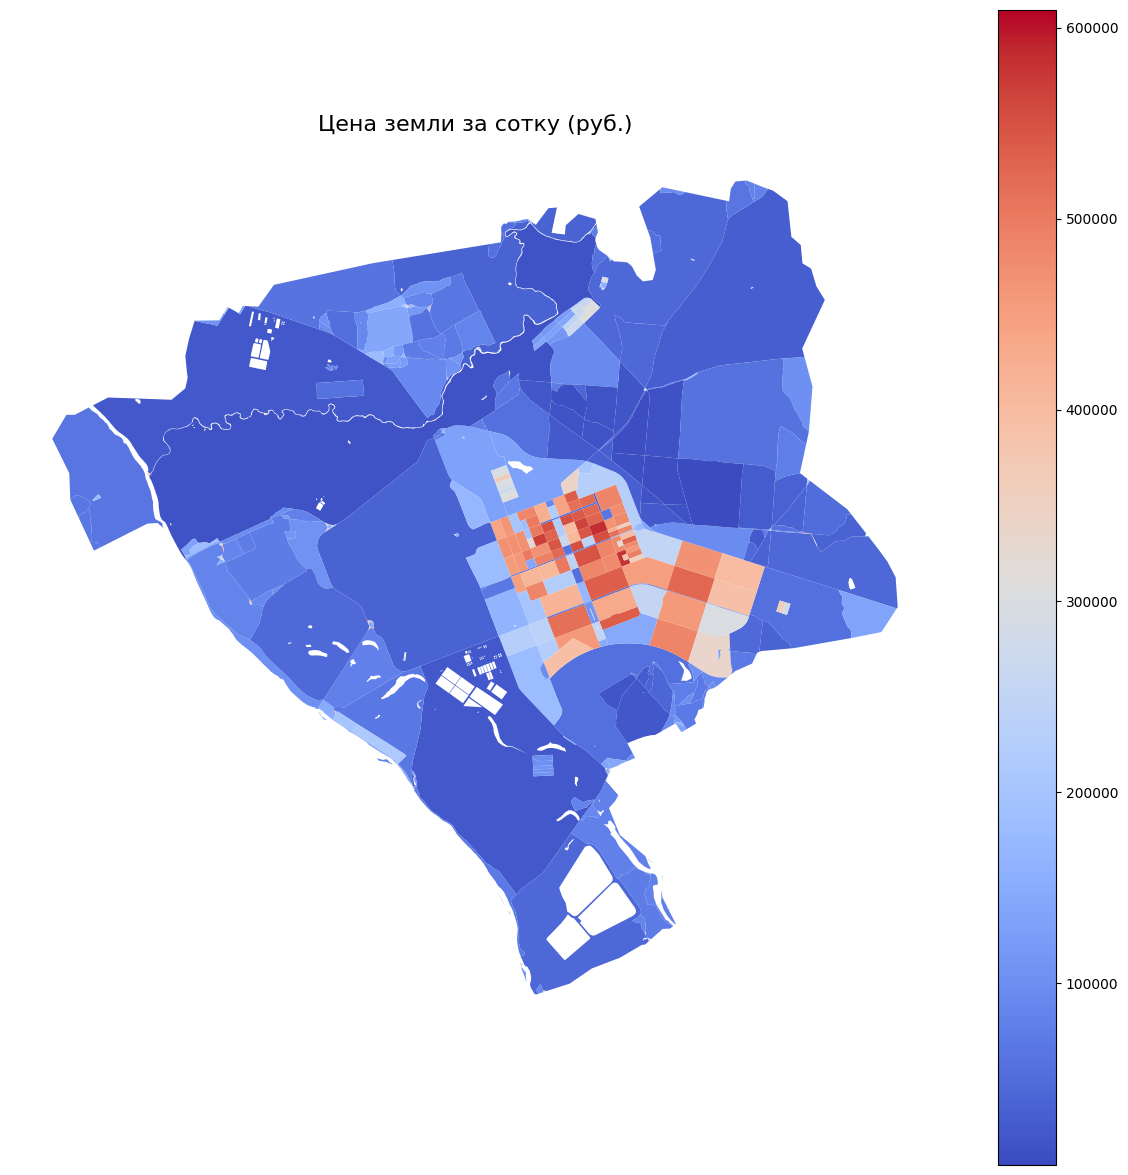

In [6]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(15,15),
    cmap='coolwarm'
).set_axis_off()
plt.title('Цена земли за сотку (руб.)', fontsize=16)

plt.show()

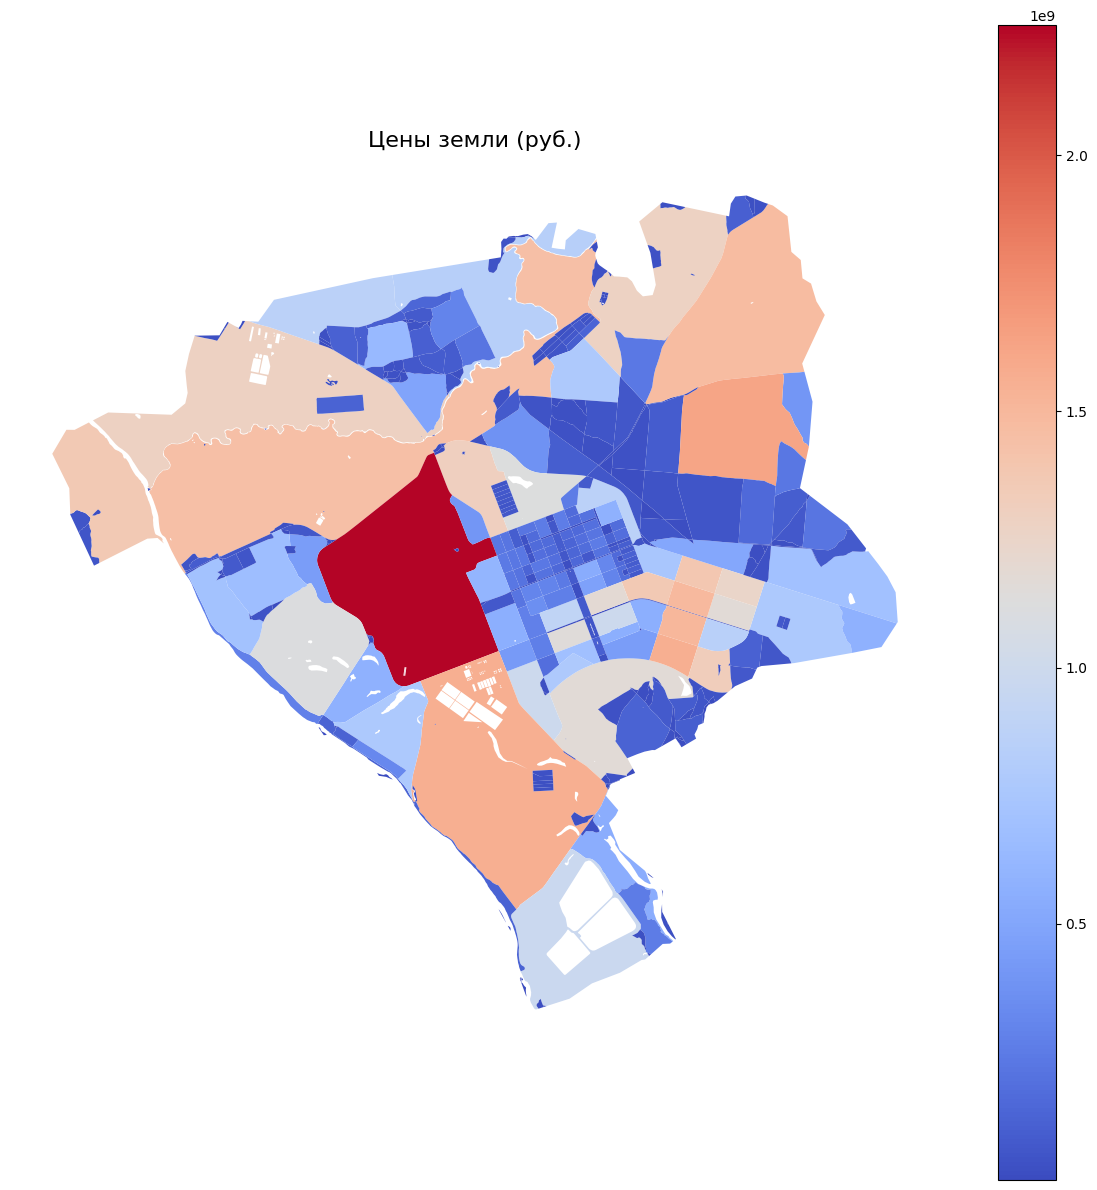

In [7]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(15,15),
    cmap='coolwarm'
).set_axis_off()
plt.title('Цены земли (руб.)', fontsize=16)

plt.show()

## Сценарное изменение земельных участков

In [8]:
blocks_clean["id"] = blocks_clean.index


/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


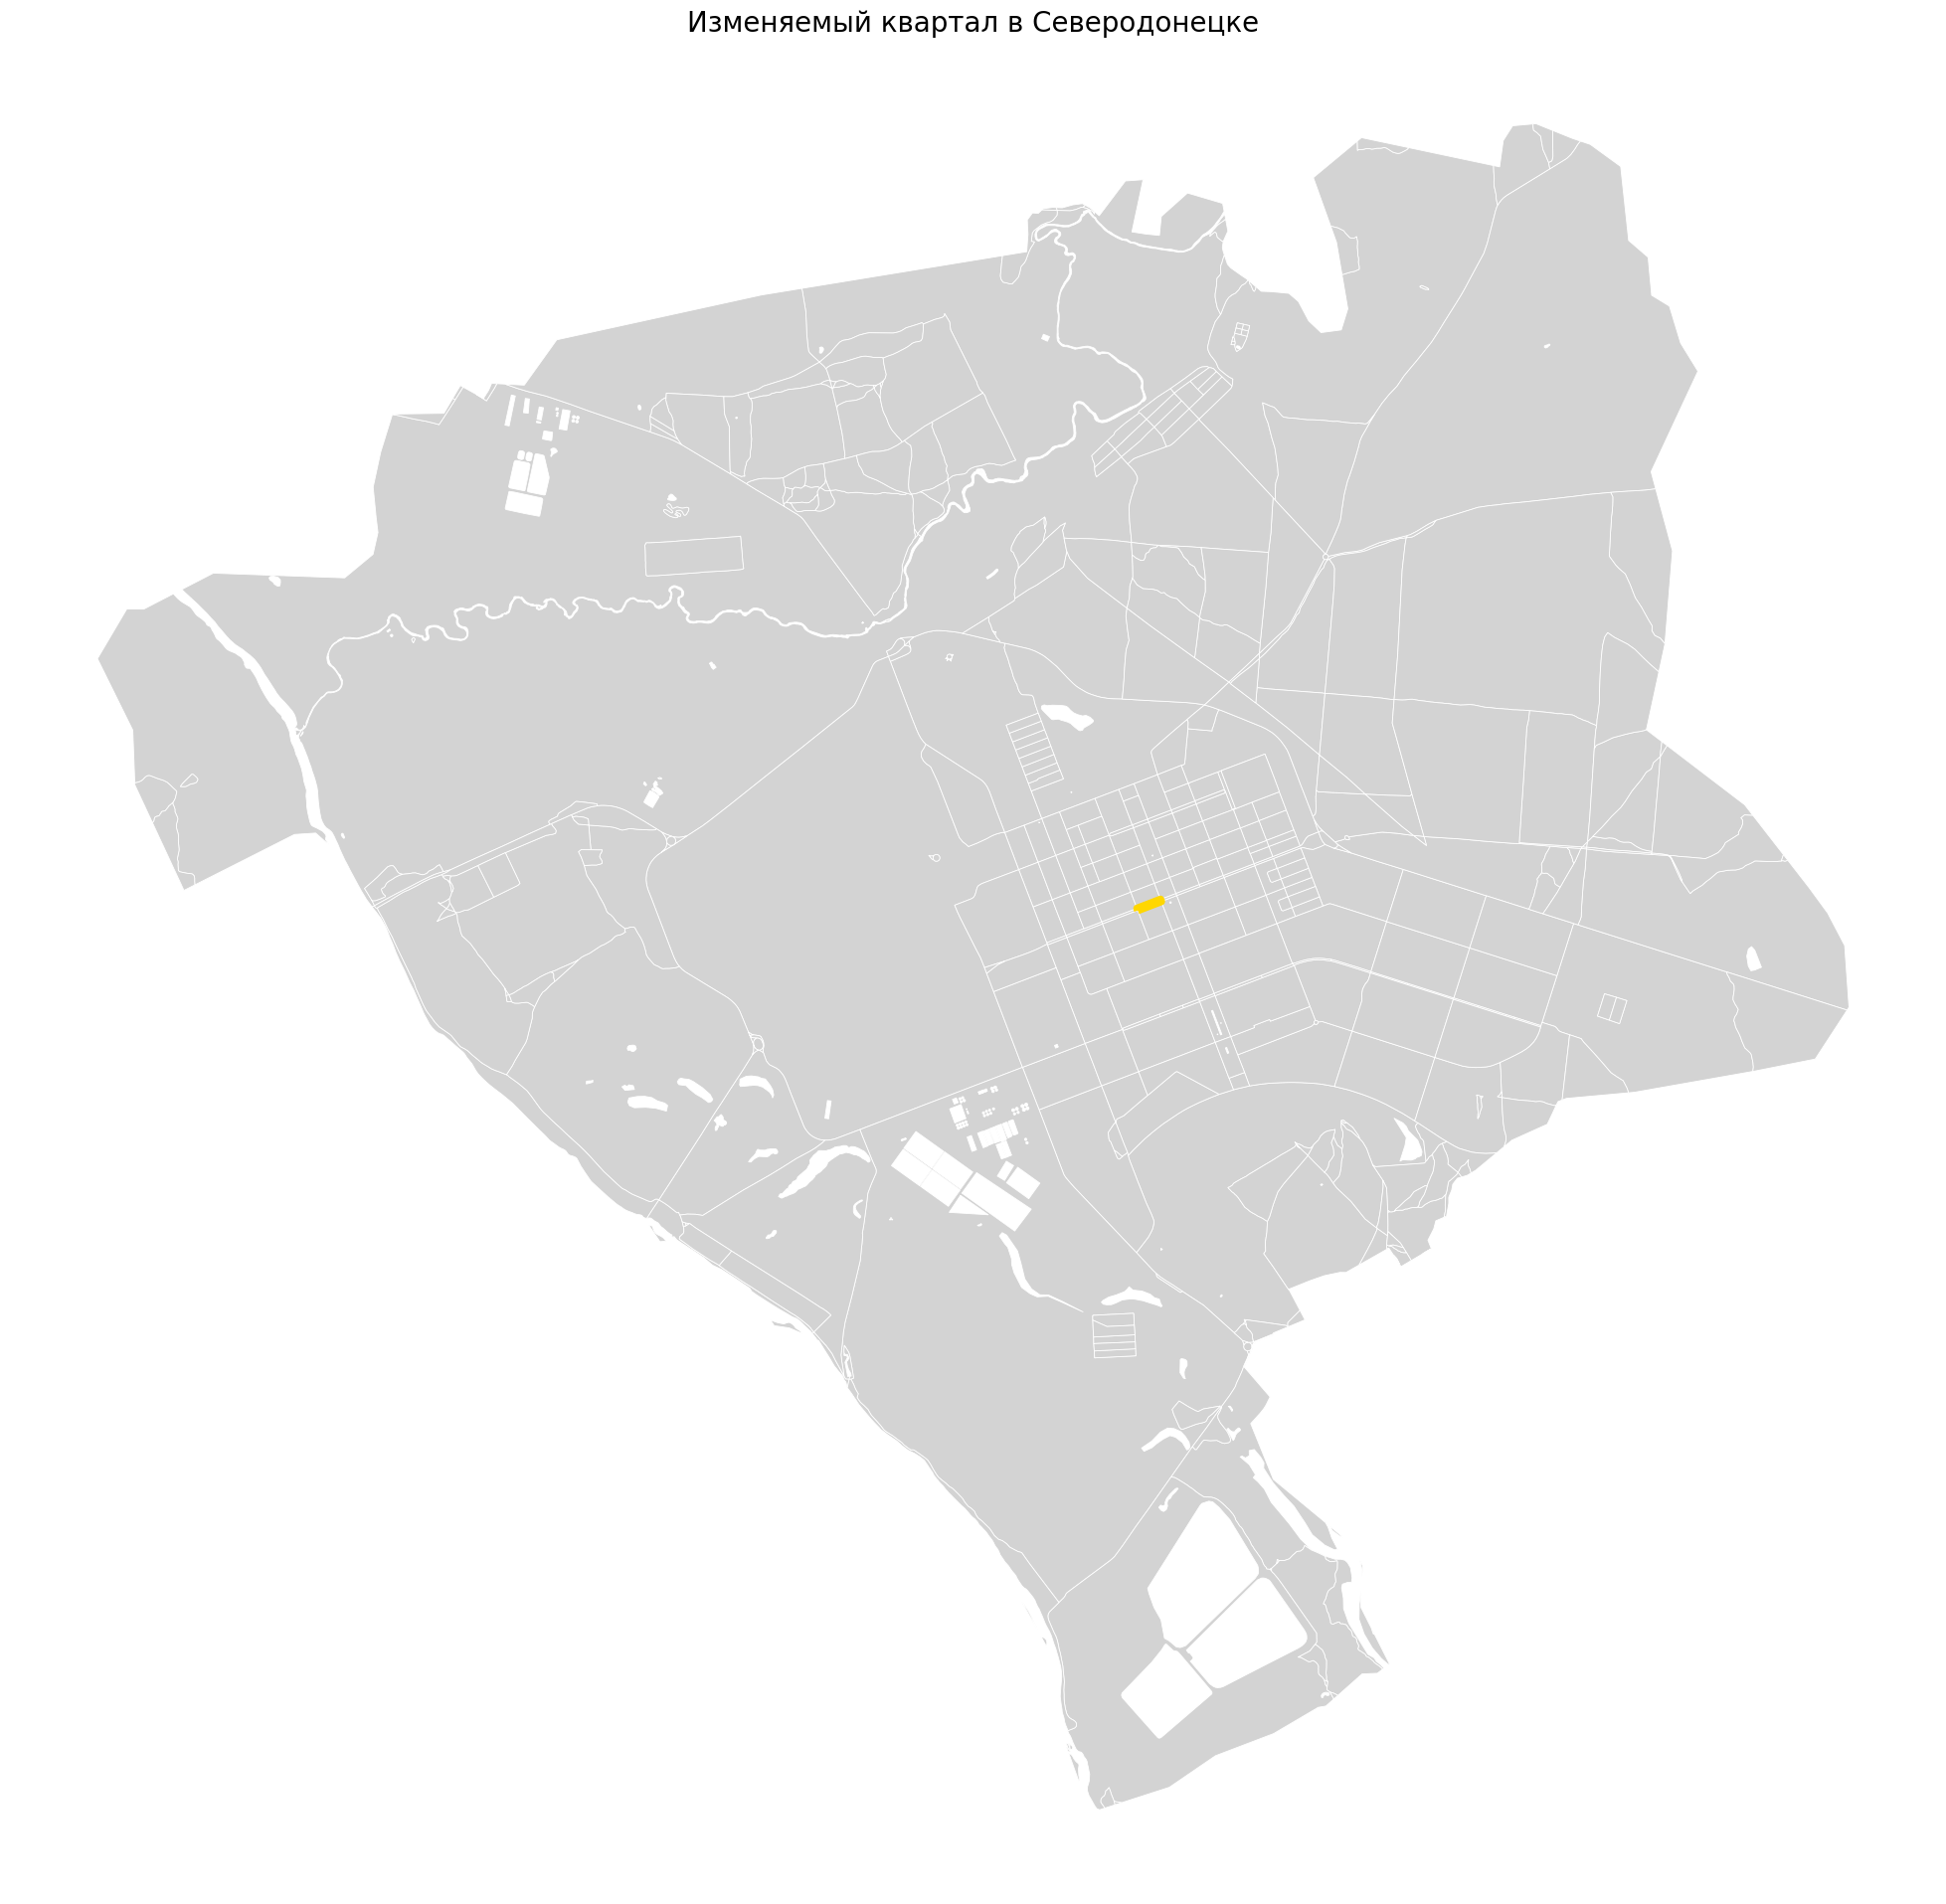

In [13]:
import matplotlib.pyplot as plt
basline_blocks["id"] = basline_blocks.index

fig, ax = plt.subplots(figsize=(25, 35))
basline_blocks.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)  # фон
basline_blocks.loc[basline_blocks["id"]==147].plot(
    ax=ax, color="none", edgecolor="gold", linewidth=5.5
)
ax.set_title("Изменяемый квартал в Северодонецке", fontsize=20)
ax.axis("off")
plt.show()

In [9]:
blocks_clean.loc[142]

residential                                                           0.0
business                                                              0.0
recreation                                                       0.916564
industrial                                                            0.0
transport                                                             0.0
special                                                               0.0
agriculture                                                           0.0
land_use                                               LandUse.RECREATION
share                                                            0.916564
footprint_area                                                1725.663559
build_floor_area                                              2742.314861
living_area                                                           0.0
non_living_area                                               2742.314861
population                            

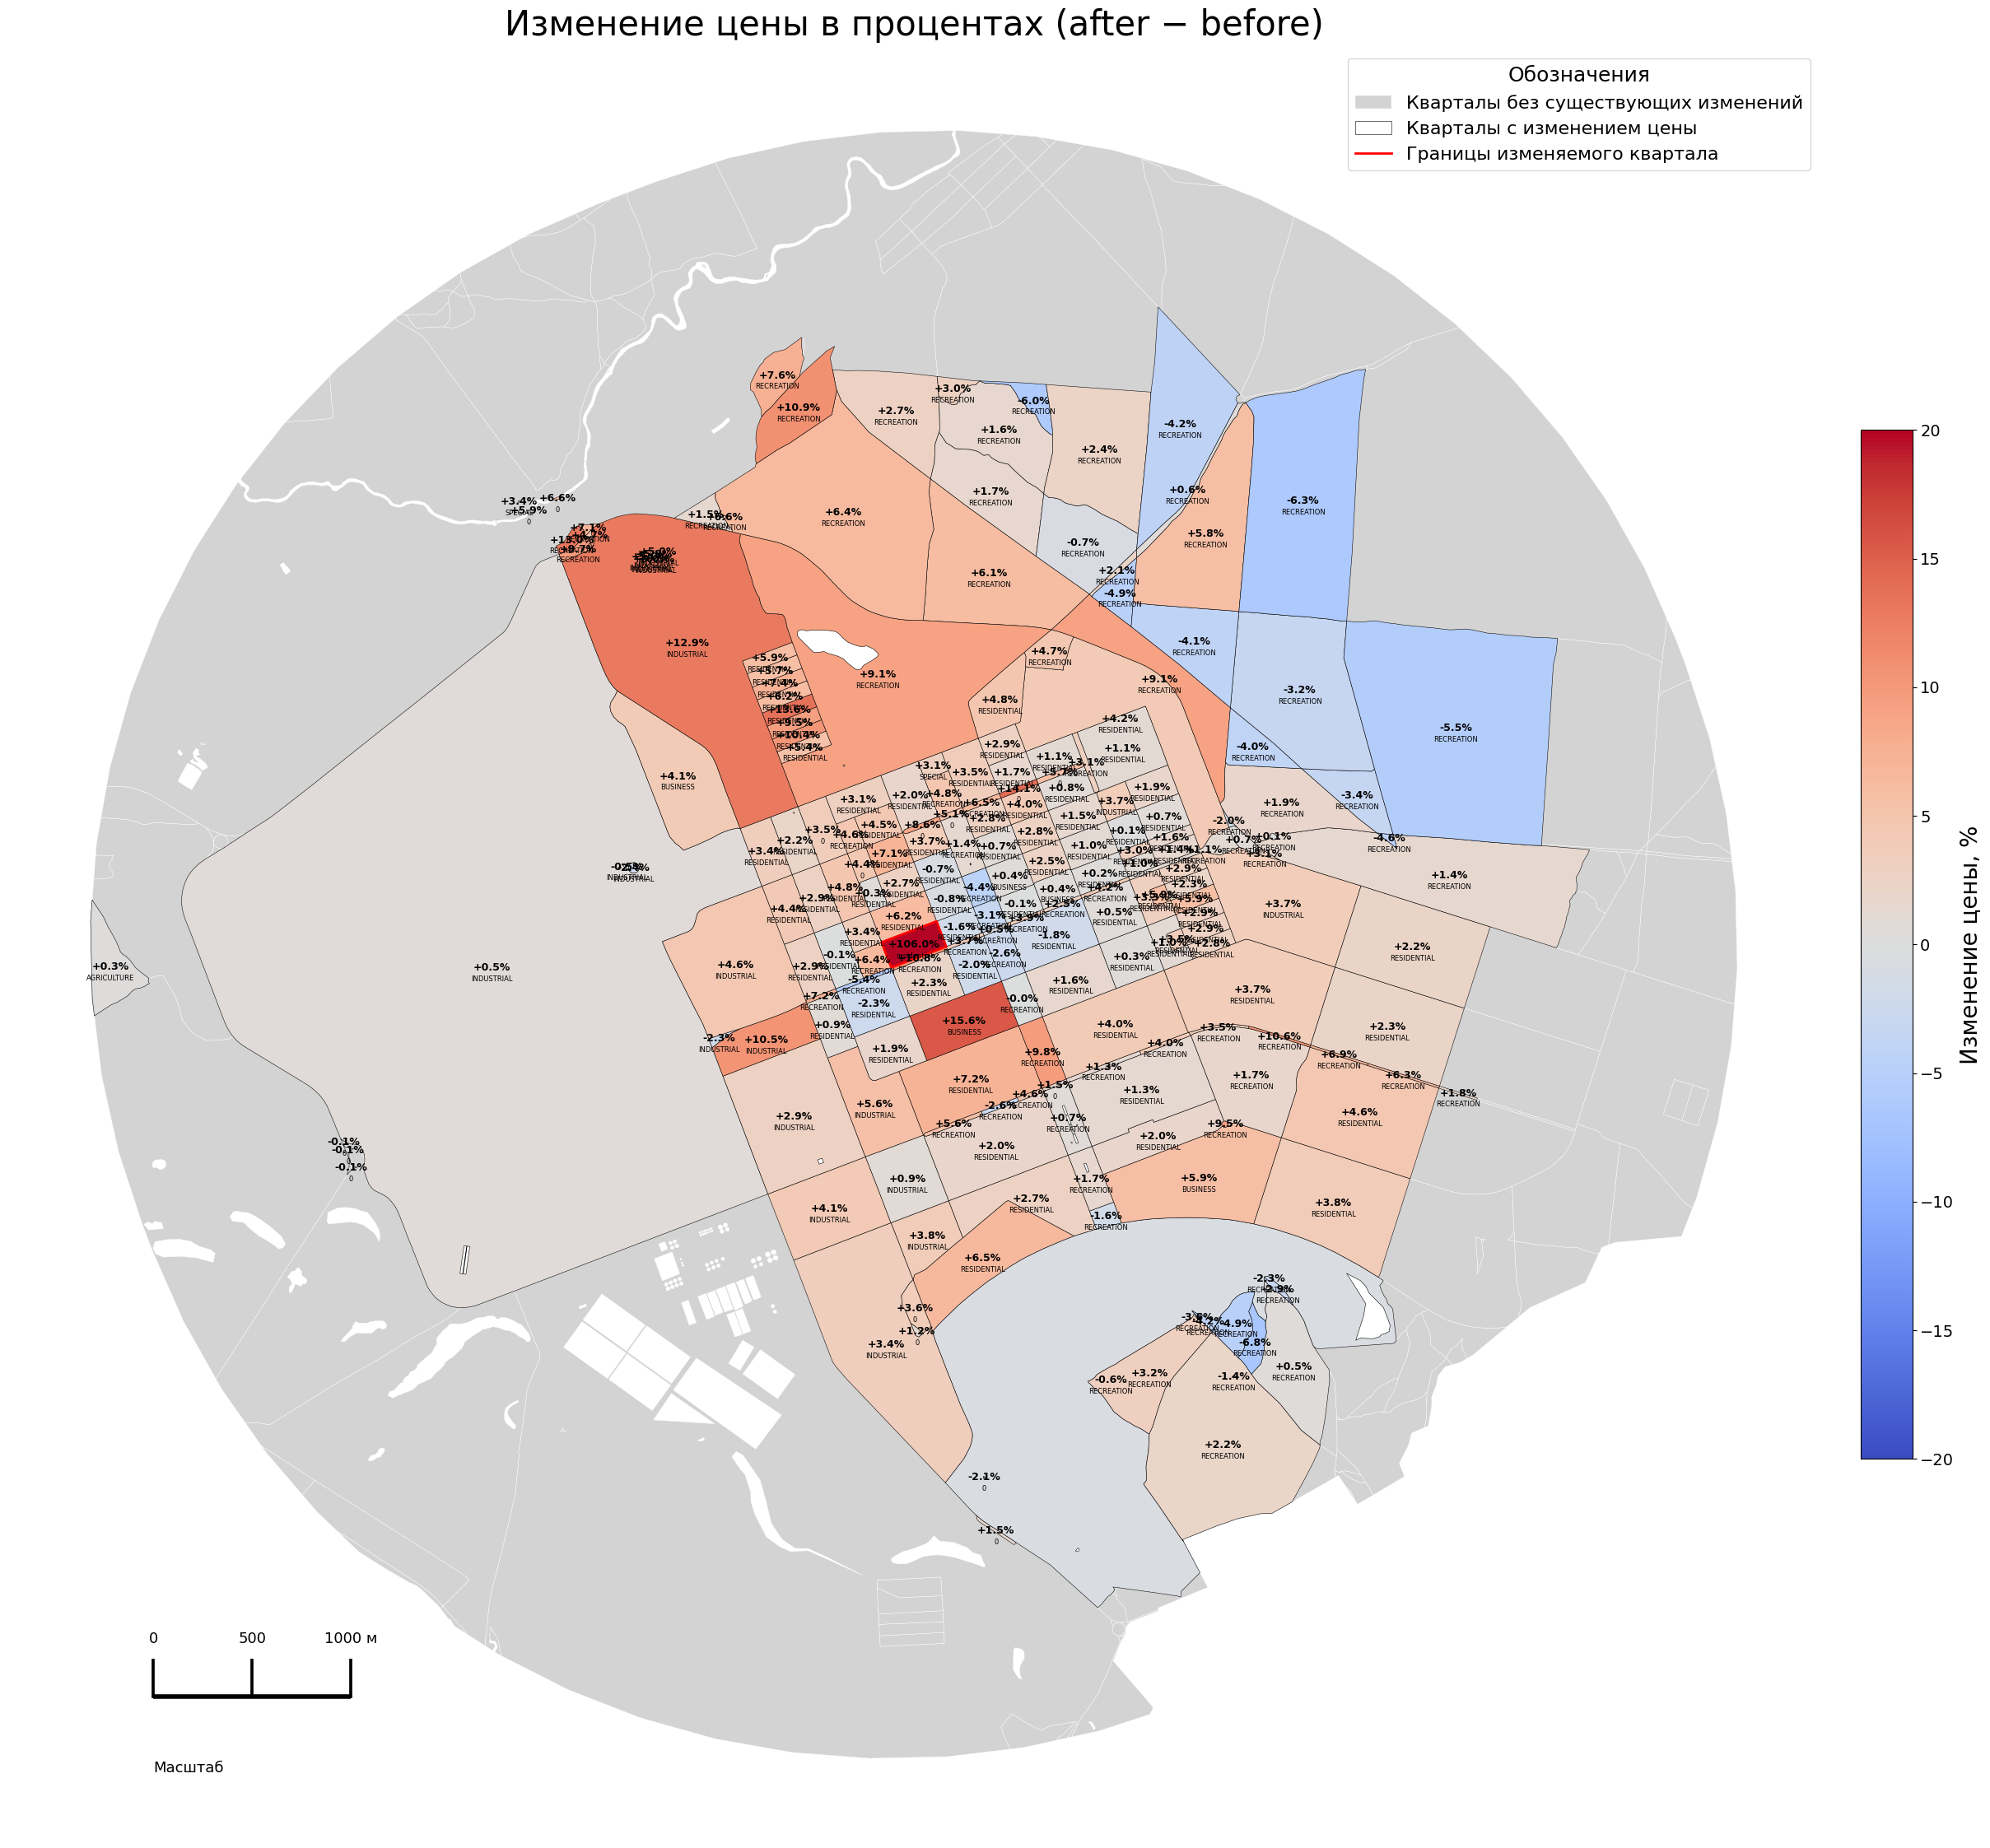


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
143 | residential | 200 762 589 ₽ → 413 611 999 ₽ | +212 849 410 ₽ | +106.0%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
318 | 0 | 4 675 799 ₽ → 4 747 709 ₽ | +71 910 ₽ | +1.5%
410 | 0 | 54 926 ₽ → 53 785 ₽ | -1 140 ₽ | -2.1%
18 | RESIDENTIAL | 777 557 767 ₽ → 828 085 339 ₽ | +50 527 573 ₽ | +6.5%
21 | INDUSTRIAL | 178 322 651 ₽ → 185 078 370 ₽ | +6 755 719 ₽ | +3.8%
193 | RESIDENTIAL | 689 297 550 ₽ → 707 923 192 ₽ | +18 625 643 ₽ | +2.7%
192 | RESIDENTIAL | 1 145 325 365 ₽ → 1 167 708 584 ₽ | +22 383 219 ₽ | +2.0%
199 | RECREATION | 2 757 017 ₽ → 2 910 195 ₽ | +153 178 ₽ | +5.6%
200 | RECREATION | 2 709 349 ₽ → 2 637 875 ₽ | -71 475 ₽ | -2.6%
7 | RECREATION | 1 168 211 837 ₽ → 1 161 403 915 ₽ | -6 807 921 ₽ | -0.6%
409 | RECREATION | 27 602 905 ₽ → 28 487 007 

In [14]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
    transfer_baseline_prices,
)

blocks_before = basline_blocks.copy()

changes = {
    # Структура использования территории
    "land_use": "LandUse.RESIDENTIAL",
    "residential": 1.0,
    "business": 0.0,
    "recreation": 0.0,
    "industrial": 0.0,
    "transport": 0.0,
    "special": 0.0,
    "agriculture": 0.0,
    "share": 1.0,

    "footprint_area": 48170.0451624,    # ≈ 60% от site_area
    "build_floor_area": 481700.451624,  # FSI ≈ 6.0
    "living_area": 337190.3161368,      # ≈ 70% 
    "non_living_area": 144510.1354872,  # ≈ 30% 
    "population": 5537,                # 


    "fsi": 6.0,                         # build_floor_area / site_area
    "gsi": 0.60,                        # footprint_area / site_area
    "l": 10.0,                          # build_floor_area / footprint_area (этажность)
                    # build_floor_area / footprint_area (этажность)

    # Морфотип – высотный дом
    "morphotype": "high-rise residential",
    }

target_idx = 143

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

# 1) Предсказание стоимости до/после
before_estimator = LandPriceEstimator(model=model, blocks=blocks_before)
after_estimator = LandPriceEstimator(model=model, blocks=blocks_after)

blocks_before_pred = before_estimator.predict()
blocks_before_pred["land_value_per_100m2"] = blocks_before_pred["land_value"] / blocks_before_pred["site_area"] * 100

blocks_after_pred = after_estimator.predict()
blocks_after_pred["land_value_per_100m2"] = blocks_after_pred["land_value"] / blocks_after_pred["site_area"] * 100

blocks_full_value = transfer_baseline_prices(
    after_blocks=blocks_after_pred,
    before_blocks=blocks_before_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 3) Только визуализация и статистика по процентным изменениям
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,          
    target_id_column="id",   # если колонка называется иначе — укажи здесь
    figsize=(25, 35),
)

# **Инвестиционная** привлекактельтность 

In [51]:
from blocksnet.enums import LandUse

benchmarks_demo = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 120_000,
        "construction_years": 3,
        "sale_years": 3,
        "opex_rate": 800,
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 12,
        "construction_years": 4,
        "opex_rate": 1_300,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 4_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 700,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 6_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}

In [52]:
from urbanomy.methods.investment_potential import prepare_investment_input


potential_df = pd.read_csv("./data/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = blocks_after,
    project_potential = potential_df,
)

investment_input.head()

,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential
0,LandUse.BUSINESS,1.967019e+08,148084272.0,159911.214374,0.0,30000.0,40000.0,1.0,4.0


In [53]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

Project totals:
 • Land area:          159,911.21
 • Built area:         30,000.00
 • Land value:         196,701,854.51
 • Construction cost:  1,650,000,000.00
 • Investment need:    1,846,701,854.51
 • Spatial potential:  4.00
 • Project NPV:        568,114,153.58
 • Project IRR:        0.24
 • Project ROI:        11.97
 • Project PP (yrs):   9.95
 • Project EI:         75.23
 • Project INV score:  44.07


,land_use,land_area,land_value_before,built_area,land_value,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.BUSINESS,159911.21,148084272.0,30000.0,1.967019e+08,1.650000e+09,1.846702e+09,5.681142e+08,0.24,11.97,9.95,75.23,4.0,44.07


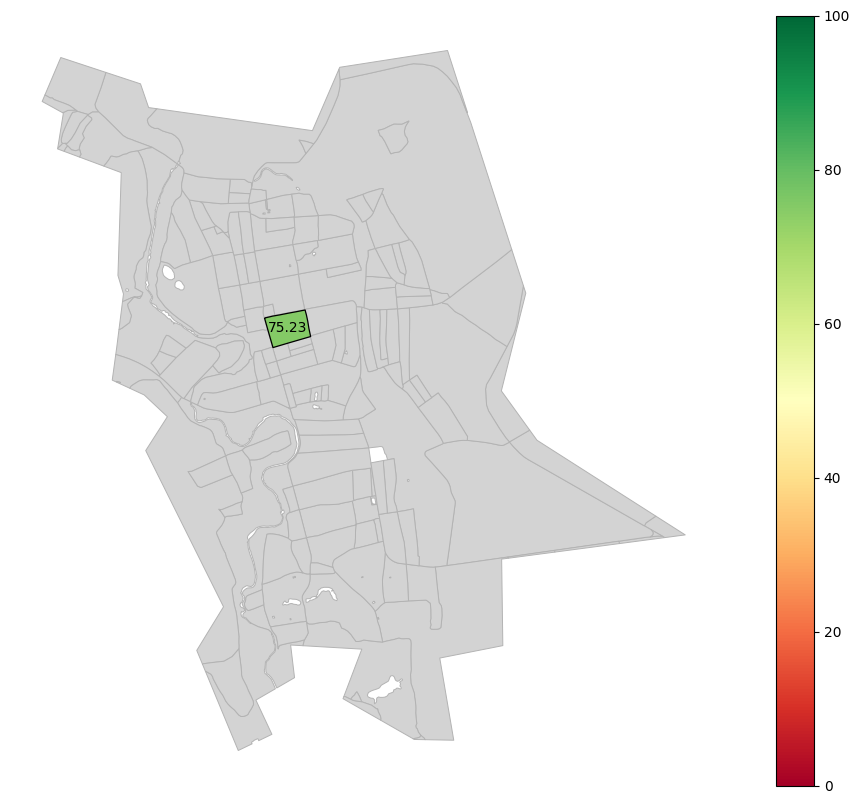

In [54]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "EI"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(15, 10))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()


In [56]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 300_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,5 500
1,Валовый региональный продукт на душу населения,3 950
2,Доходы бюджета территории,921 620 264
3,Средний уровень заработной платы,129
4,Износ основного фонда (тыс. руб.),47 025
